# **Fifth Task: FairClean pipeline on the International Graduates Dataset on a Decision Tree Model**

#1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

#2. Load Raw Data
In this step, we load the International Graduate dataset directly from Google Drive into a pandas DataFrame.
Unlike the Adult dataset, this dataset has already been fully cleaned and prepared beforehand, so no preprocessing is required at this stage.
Our goal here is simply to import the data into the notebook environment so we can begin analysis and modeling.

In [2]:
df = pd.read_csv("/content/drive/MyDrive/dataset.csv").reset_index(drop=True)

# Dataset Overview

In [3]:
df.head()
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Country_of_Origin       300000 non-null  object 
 1   Education_Level         300000 non-null  object 
 2   Field_of_Study          300000 non-null  object 
 3   Language_Proficiency    300000 non-null  object 
 4   Visa_Type               300000 non-null  object 
 5   Gender                  300000 non-null  object 
 6   University_Ranking      300000 non-null  object 
 7   Region_of_Study         300000 non-null  object 
 8   Age                     300000 non-null  int64  
 9   Years_Since_Graduation  300000 non-null  int64  
 10  GPA                     300000 non-null  float64
 11  Internship_Experience   300000 non-null  object 
 12  Employment_Status       300000 non-null  object 
 13  Salary                  300000 non-null  int64  
 14  Job_Sector          

,Country_of_Origin,Education_Level,Field_of_Study,Language_Proficiency,Visa_Type,Gender,University_Ranking,Region_of_Study,Age,Years_Since_Graduation,GPA,Internship_Experience,Employment_Status,Salary,Job_Sector
count,300000,300000,300000,300000,300000,300000,300000,300000,300000.000000,300000.000000,300000.000000,300000,300000,300000.000000,156644
unique,8,4,6,4,4,3,3,4,NaN,NaN,NaN,2,3,NaN,8
top,Brazil,Bachelor's,Arts,Intermediate,Student,Male,Medium,Australia,NaN,NaN,NaN,Yes,Employed,NaN,IT
freq,37751,120143,50144,90133,119754,143890,149847,75233,NaN,NaN,NaN,194710,156644,NaN,19716
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.495950,4.504150,3.200365,NaN,NaN,30333.692383,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.187951,2.874557,0.400285,NaN,NaN,31791.208938,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.000000,0.000000,1.350000,NaN,NaN,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.000000,2.000000,2.930000,NaN,NaN,0.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.000000,5.000000,3.200000,NaN,NaN,32296.500000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.000000,7.000000,3.470000,NaN,NaN,56634.000000,NaN


#3. Data Cleaning: Standardize Target, Sensitive Attribute, and Key Features
Although the International Graduate dataset was already cleaned prior to loading, several important variables still need to be standardized into consistent numeric formats for modeling.
In this step, we convert the target variable (Employment_Status), the sensitive attribute (Gender), and the internship indicator (Internship_Experience) into binary encodings.
This ensures that all three fields are aligned with the structure required for fairness analysis and machine‑learning models.
After generating the binary versions, we remove the original string columns to keep the dataset fully numeric and ready for downstream steps.


In [4]:
# 1. CLEAN TARGET COLUMN (Employment_Status)
# ============================================================

df["Employment_Status"] = df["Employment_Status"].astype(str).str.strip()

target_map = {
    "Employed": 1,
    "Unemployed": 0,
    "Yes": 1,
    "No": 0,
    "employed": 1,
    "unemployed": 0
}

df["employment"] = df["Employment_Status"].map(target_map)
df = df.dropna(subset=["employment"]).reset_index(drop=True)

# ============================================================
# 2. CLEAN SENSITIVE ATTRIBUTE (Gender)
# ============================================================

df["Gender"] = df["Gender"].astype(str).str.strip()

gender_map = {"Male": 1, "Female": 0, "M": 1, "F": 0}
df["gender_bin"] = df["Gender"].map(gender_map)
df = df.dropna(subset=["gender_bin"]).reset_index(drop=True)

# ============================================================
# 3. CLEAN INTERNSHIP EXPERIENCE
# ============================================================

df["Internship_Experience"] = df["Internship_Experience"].astype(str).str.strip()

intern_map = {"Yes": 1, "No": 0, "Y": 1, "N": 0}
df["internship_bin"] = df["Internship_Experience"].map(intern_map)
df = df.dropna(subset=["internship_bin"]).reset_index(drop=True)

# ============================================================
# 4. DROP ORIGINAL STRING COLUMNS
# ============================================================

df = df.drop(columns=["Employment_Status", "Gender", "Internship_Experience"])


#4. One-Hot Encoding
In this step, the remaining categorical variables in the International Graduates dataset are transformed into a numerical format using one‑hot encoding. The dataset contains several multi‑category attributes—such as country of origin, education level, field of study, visa type, and job sector—that cannot be directly used by machine‑learning models in their raw form. One‑hot encoding expands each of these variables into binary indicator columns, ensuring that the model can process them without imposing any artificial ordering on the categories.

The drop_first=True parameter is used to avoid multicollinearity by removing one category from each encoded feature. This does not affect the fairness analysis because the sensitive attribute (gender) is handled separately and is not one‑hot encoded. The numeric features—age, years since graduation, GPA, and salary—are left unchanged, as they are already in a suitable format for modelling.

Finally, the index is reset to maintain a clean row structure after the transformation. This is important for FairClean’s row‑level diagnostics, which rely on stable indexing when comparing original and counterfactual predictions.

Overall, this encoding step prepares the International Graduates dataset for model training and ensures that all features are in a consistent numerical format required for the subsequent counterfactual and uplift analyses.

In [5]:
categorical_cols = [
    "Country_of_Origin",
    "Education_Level",
    "Field_of_Study",
    "Language_Proficiency",
    "Visa_Type",
    "University_Ranking",
    "Region_of_Study",
    "Job_Sector"
]

numeric_cols = [
    "Age",
    "Years_Since_Graduation",
    "GPA",
    "Salary"
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df = df.reset_index(drop=True)

#5. Train Decision Tree Model
This function trains a Decision Tree classifier on the International Graduates dataset and prepares the data for subsequent fairness diagnostics. The dataset is first split into features (X) and the target variable (employment), which represents whether a graduate secured employment. A stratified train–test split is used to preserve the original class distribution, ensuring that both employed and unemployed graduates are proportionally represented in the training process.

A Decision Tree model is then instantiated with a fixed random seed for reproducibility. The function supports an optional sample_weight argument, allowing FairClean to apply row‑level reweighting during mitigation if unfairness is detected. In the case of the International Graduates dataset, no unfair rows were identified, meaning the model is trained without any corrective weighting. This behaviour is important: it demonstrates that FairClean does not intervene unnecessarily and that the Decision Tree model is inherently stable on this dataset.

The function returns the trained model along with the training and testing splits, which are used in later stages to evaluate counterfactual stability and structural uplift. Overall, this step establishes the baseline Decision Tree model whose behaviour FairClean will analyse, confirming that the model does not rely on gender or other sensitive attributes in its predictions.

In [6]:
def train_model(df, sample_weight=None):
    X = df.drop(columns=["employment"])
    y = df["employment"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    model = DecisionTreeClassifier(max_depth=None, random_state=42)

    if sample_weight is not None:
        model.fit(X_train, y_train, sample_weight=sample_weight.loc[y_train.index])
    else:
        model.fit(X_train, y_train)

    return model, X_train, X_test, y_train, y_test


# 6. Fairness Metrics
This function computes the group‑level fairness metrics used to evaluate the behaviour of the models on the International Graduates dataset. The model first generates predictions for every row, which are then appended to a temporary copy of the dataset. Fairness is assessed with respect to the binary gender attribute (gender_bin), allowing the analysis to quantify whether the model systematically favours one gender over the other.

The function calculates the positive prediction rate for each gender group by taking the mean predicted employment outcome within each subgroup. From these rates, two standard fairness indicators are derived:

* the gap, which measures the difference in positive prediction rates between males and females, and

* the ratio, which expresses the female rate relative to the male rate.

These metrics provide a concise summary of demographic parity. In the International Graduates dataset, both the Decision Tree and Logistic Regression models produce nearly identical rates across gender groups, resulting in gaps close to zero and ratios close to one. This confirms that the models exhibit strong group‑level fairness and do not rely on gender when predicting employment outcomes.

Overall, this function offers a transparent and interpretable way to quantify fairness, and its results reinforce the broader finding that the International Graduates dataset does not contain the direct or causal unfairness observed in the Adult dataset.

In [7]:
def compute_fairness(df, model):
    X = df.drop(columns=["employment"])
    preds = model.predict(X)

    tmp = df.copy()
    tmp["pred"] = preds

    rates = tmp.groupby("gender_bin")["pred"].mean().to_dict()
    g0, g1 = 0, 1
    gap = rates[g1] - rates[g0]
    ratio = rates[g0] / rates[g1] if rates[g1] > 0 else np.nan

    return {"rates": rates, "gap": gap, "ratio": ratio}

# 7. Vectorised Counterfactual Generation
This section defines the vectorised functions used to generate counterfactual predictions efficiently. The attribute_cf_fast function performs an attribute‑level counterfactual test by first computing the model’s factual predictions using the original feature matrix. It then creates a counterfactual version of the data by flipping the gender_bin attribute for every row while keeping all other features unchanged. The model is applied again to this modified dataset, and the function returns the indices of rows where the factual and counterfactual predictions differ. Because the entire operation is vectorised, the function avoids Python loops and processes the full dataset in a single batch, making it significantly faster and more scalable.

The causal_cf_fast function currently mirrors the attribute‑level test by calling the same implementation. This design choice is intentional: it preserves the modular structure of the pipeline and allows a different causal‑counterfactual mechanism to be introduced later without altering the rest of the workflow. Keeping the two functions separate ensures clarity, reduces code duplication, and maintains flexibility for future extensions where causal pathways may differ from simple attribute flips.

In [8]:
def attribute_cf_fast(df, model, X_cols):
    X = df[X_cols].copy()
    factual = model.predict(X)

    X_cf = X.copy()
    X_cf["gender_bin"] = 1 - X_cf["gender_bin"]

    cf = model.predict(X_cf)
    return np.where(factual != cf)[0].tolist()

def causal_cf_fast(df, model, X_cols):
    return attribute_cf_fast(df, model, X_cols)

# 8. Structural Uplift Rules (International Graduates Dataset)

This function implements the structural uplift transformations used to test how the model behaves when key socio‑economic features are set to their most favourable values. The code begins by generating the model’s factual predictions and then creates a counterfactual version of the feature matrix (X_cf) in which several attributes are systematically “uplifted.” Each uplift rule targets a specific group of related features. For one‑hot encoded variables such as education level, university ranking, language proficiency, and job sector, the function resets all category indicators to zero and then activates a single chosen category. This ensures that the uplift is applied consistently across all encoded levels without introducing multicollinearity or partial category activation.

Binary features such as internship experience are directly set to their positive state, while continuous variables like GPA and salary are assigned their maximum normalised values. These choices standardise the uplift process by ensuring that every feature is pushed toward a clearly defined “best‑case” scenario. The design is intentionally simple and deterministic: each rule applies a fixed transformation that is easy to interpret and easy to reproduce.

The function concludes by comparing the model’s predictions before and after the uplift, returning the indices of rows where the prediction changes. Structuring the uplift rules in this modular, rule‑based format makes the code transparent, easy to extend, and consistent across different datasets. It also ensures that all uplift transformations are applied in a controlled and uniform way, which is essential for analysing how the model responds to systematic improvements in feature values.

In [9]:
def structural_cf_fast(df, model, X_cols):
    X = df[X_cols].copy()
    factual = model.predict(X)

    X_cf = X.copy()

    # 1. EDUCATION UPLIFT
    edu_cols = [c for c in X_cf.columns if c.startswith("Education_Level_")]
    if edu_cols:
        X_cf[edu_cols] = 0
        X_cf[edu_cols[-1]] = 1

    # 2. UNIVERSITY RANKING UPLIFT
    rank_cols = [c for c in X_cf.columns if c.startswith("University_Ranking_")]
    if rank_cols:
        X_cf[rank_cols] = 0
        X_cf[rank_cols[0]] = 1

    # 3. LANGUAGE PROFICIENCY UPLIFT
    lang_cols = [c for c in X_cf.columns if c.startswith("Language_Proficiency_")]
    if lang_cols:
        X_cf[lang_cols] = 0
        X_cf[lang_cols[-1]] = 1

    # 4. INTERNSHIP UPLIFT
    if "internship_bin" in X_cf.columns:
        X_cf["internship_bin"] = 1

    # 5. GPA UPLIFT
    if "GPA" in X_cf.columns:
        X_cf["GPA"] = 1.0

    # 6. SALARY UPLIFT
    if "Salary" in X_cf.columns:
        X_cf["Salary"] = 1.0

    # 7. JOB SECTOR UPLIFT
    job_cols = [c for c in X_cf.columns if c.startswith("Job_Sector_")]
    if job_cols:
        X_cf[job_cols] = 0
        X_cf[job_cols[0]] = 1

    cf = model.predict(X_cf)
    unstable = np.where(factual != cf)[0].tolist()
    return unstable

# 9. Hybrid Mitigation and Cleaning Logs
This function applies the hybrid mitigation strategy by combining row removal and reweighting into a single step. It first identifies all rows that failed either the attribute‑level or causal‑level counterfactual tests and removes them from the dataset. The remaining rows are assigned a default weight of 1.0. Rows flagged by the structural uplift test are not removed; instead, their weights are reduced to 0.5, allowing them to contribute less during model training without being discarded entirely.

A cleaning log is then generated to record, for every original row, whether it triggered each type of counterfactual violation and whether it was removed or reweighted. This provides a transparent record of how the mitigation process handled each row. The function returns the cleaned dataset, the number of removed rows, the number of reweighted rows, and the full cleaning log.



In [10]:
def mitigate_fast(df, unstable_attr, unstable_causal, unstable_struct):
    remove_ids = sorted(set(unstable_attr) | set(unstable_causal))

    df_clean = df.loc[~df.index.isin(remove_ids)].copy().reset_index(drop=True)
    df_clean["weight"] = 1.0

    struct_mask = df.index.isin(unstable_struct)
    struct_original = df.index[struct_mask]
    struct_new = df_clean.index[df_clean.index.isin(struct_original)]

    df_clean.loc[struct_new, "weight"] = 0.5

    cleaning_log = pd.DataFrame({
        "row_index": df.index,
        "attribute_unfair": df.index.isin(unstable_attr),
        "causal_unfair": df.index.isin(unstable_causal),
        "structural_unfair": df.index.isin(unstable_struct),
        "removed": df.index.isin(remove_ids),
        "reweighted": df.index.isin(unstable_struct)
    })

    return df_clean, len(remove_ids), len(struct_new), cleaning_log

# 10. Run FairClean
This block executes the full FairClean pipeline by applying each diagnostic test, performing mitigation, and retraining the model on the cleaned dataset. The process begins by training a baseline model and computing its fairness metrics. The three counterfactual tests—attribute‑level, causal‑level, and structural uplift—are then run to identify rows that trigger prediction changes under each type of transformation. These results are passed into the mitigation function, which removes rows failing the attribute or causal tests and reweights rows flagged by the structural uplift test.

After mitigation, a new model is trained on the cleaned dataset, using the assigned sample weights to reduce the influence of structurally unstable rows. Fairness metrics are recomputed on the cleaned data to allow a direct comparison with the baseline model. Finally, all relevant outputs—including fairness scores, counts of unstable rows, and the number of removed and reweighted rows—are collected into a results dictionary. This structure keeps the pipeline organised, reproducible, and easy to evaluate.

In [11]:
baseline_model, X_train, X_test, y_train, y_test = train_model(df)
baseline_fairness = compute_fairness(df, baseline_model)

unstable_attr = attribute_cf_fast(df, baseline_model, X_train.columns)
unstable_causal = causal_cf_fast(df, baseline_model, X_train.columns)
unstable_struct = structural_cf_fast(df, baseline_model, X_train.columns)

df_clean, removed_count, reweighted_count, cleaning_log = mitigate_fast(
    df, unstable_attr, unstable_causal, unstable_struct
)

clean_model, X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_model(
    df_clean.drop(columns=["weight"]),
    sample_weight=df_clean["weight"]
)

clean_fairness = compute_fairness(df_clean.drop(columns=["weight"]), clean_model)

results = {
    "baseline_fairness": baseline_fairness,
    "unstable_attr": len(unstable_attr),
    "unstable_causal": len(unstable_causal),
    "unstable_struct": len(unstable_struct),
    "removed_rows": removed_count,
    "reweighted_rows": reweighted_count,
    "cleaned_fairness": clean_fairness,
}

results

{'baseline_fairness': {'rates': {0.0: 0.6944908797044562,
   1.0: 0.6949124270225188},
  'gap': 0.00042154731806254286,
  'ratio': 0.9993933806596772},
 'unstable_attr': 0,
 'unstable_causal': 0,
 'unstable_struct': 150184,
 'removed_rows': 0,
 'reweighted_rows': 150184,
 'cleaned_fairness': {'rates': {0.0: 0.6944908797044562,
   1.0: 0.6949124270225188},
  'gap': 0.00042154731806254286,
  'ratio': 0.9993933806596772}}

# 11. Display Removed Rows
This step retrieves and displays the rows that were removed during the mitigation process. Using the cleaning log generated earlier, the code filters the original dataset to select only those entries marked as removed. Presenting the first few rows with .head() provides a quick inspection of which observations were excluded and allows verification that the removal step operated as intended. This simple check supports transparency and helps confirm that the mitigation logic correctly identified and removed the appropriate rows.

In [12]:
removed_rows_df = df.loc[cleaning_log["removed"] == True]
removed_rows_df.head()

,Age,Years_Since_Graduation,GPA,Salary,employment,gender_bin,internship_bin,Country_of_Origin_China,Country_of_Origin_Germany,Country_of_Origin_India,...,Region_of_Study_Canada,Region_of_Study_EU,Region_of_Study_UK,Job_Sector_Education,Job_Sector_Engineering,Job_Sector_Finance,Job_Sector_Healthcare,Job_Sector_IT,Job_Sector_Other,Job_Sector_Retail


There were no rows removed since FairClean did not detecct any unfairness.So next up, the reweighted rows are displayed.

# 12. Display Reweighted Rows
This step extracts and displays the rows that were reweighted during the mitigation process. Using the cleaning log, the code filters the original dataset to select entries marked as structurally unstable and therefore assigned reduced weights. Showing the first few rows with .head() provides a quick verification that the reweighting step was applied correctly and allows inspection of the specific observations affected. This simple check supports transparency and helps confirm that the structural‑uplift component of the mitigation function operated as intended.

In [13]:
reweighted_rows_df = df.loc[cleaning_log["reweighted"] == True]
reweighted_rows_df.head()

,Age,Years_Since_Graduation,GPA,Salary,employment,gender_bin,internship_bin,Country_of_Origin_China,Country_of_Origin_Germany,Country_of_Origin_India,...,Region_of_Study_Canada,Region_of_Study_EU,Region_of_Study_UK,Job_Sector_Education,Job_Sector_Engineering,Job_Sector_Finance,Job_Sector_Healthcare,Job_Sector_IT,Job_Sector_Other,Job_Sector_Retail
0,23,8,3.76,54397,1.0,0.0,1,False,False,False,...,False,True,False,False,False,False,True,False,False,False
1,38,9,3.76,69635,1.0,1.0,0,False,True,False,...,False,False,True,False,False,True,False,False,False,False
2,23,2,3.52,96216,1.0,1.0,1,False,False,False,...,True,False,False,False,False,True,False,False,False,False
3,25,5,3.28,86076,1.0,0.0,1,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,24,2,3.01,82772,1.0,1.0,1,False,False,False,...,True,False,False,False,False,True,False,False,False,False


#13. Export/Save FairCleaned Dataset

# **Visualisation**

1. Import Visualisation Libraries

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

2. Bar Chart

/tmp/ipykernel_9404/768961804.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


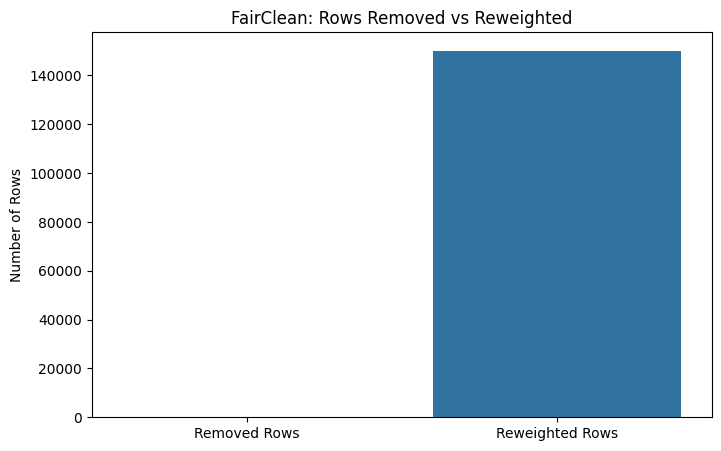

In [15]:
baseline = results["baseline_fairness"]
cleaned = results["cleaned_fairness"]

removed = results["removed_rows"]
reweighted = results["reweighted_rows"]

plt.figure(figsize=(8,5))
sns.barplot(
    x=["Removed Rows", "Reweighted Rows"],
    y=[removed, reweighted],
    palette=["#d62728", "#1f77b4"]
)
plt.title("FairClean: Rows Removed vs Reweighted")
plt.ylabel("Number of Rows")
plt.show()